# 07 — Baseline: Regresion logistica multiclase

Primer modelo del proyecto. Objetivos:

1. **Establecer un *baseline* honesto** contra el cual comparar SVM, RF y Gradient Boosting (notebooks 08-09).
2. **Ganar comprension** del problema: ¿separabilidad lineal? ¿que tan ruidoso? ¿necesitamos modelos no lineales?
3. **Producir curvas de aprendizaje y validacion** que permitan justificar la siguiente decision (mas datos, mas modelo, mas regularizacion, mejor *feature engineering*).
4. **Registrar todo en MLflow** (experimento `baseline_logistic` en DagsHub).

## Metricas del proyecto

Definidas en `README.md`:

| Metrica | Valor deseable | Por que |
|---------|----------------|---------|
| `recall_critico` | > 0.85 | NO detectar un mes critico cuesta vidas |
| `precision_critico` | > 0.70 | Falsa alarma sobre-asigna recursos y descubre otros munis |
| `f1_macro` | > 0.65 | Balance general entre las 4 clases |

## *Grid* de hiperparametros

| Hiperparametro | Valores | Motivo |
|----------------|---------|--------|
| `C` | [0.01, 0.1, 1.0, 10.0] | Cubre 4 ordenes de magnitud de regularizacion |
| `penalty` | [`l1`, `l2`] | l1 hace seleccion implicita, l2 no |
| `class_weight` | [`balanced`, `None`] | Clase `critico` es rara — *balanced* ajusta pesos inversos |

32 combinaciones x `TimeSeriesSplit(5)` = 160 *fits*.

## Salidas

- Modelo *best* en `models/logreg_best.joblib`
- Figuras (confusion, curvas) en `reports/figures/07_*.png`
- Run en MLflow (`baseline_logistic` experiment)

## 1. Imports

In [1]:
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    TimeSeriesSplit,
    learning_curve,
    validation_curve,
)

from sonalert.config import FIGURES_DIR, MODELS_DIR, PROCESSED_DATA_DIR, PROJ_ROOT

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
CLASS_NAMES = ["bajo", "medio", "alto", "critico"]
CRITICO = 3

2026-05-17 18:15:19.493 | INFO     | sonalert.config:<module>:11 - PROJ_ROOT path is: C:\Users\Santy\Documents\GitHub\sonAlert


In [2]:
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI")
MLFLOW_ACTIVE = bool(MLFLOW_URI)

if MLFLOW_ACTIVE:
    import mlflow
    import mlflow.sklearn

    mlflow.set_tracking_uri(MLFLOW_URI)
    mlflow.set_experiment("baseline_logistic")
    print(f"[MLflow] activo, tracking a: {MLFLOW_URI}")
else:
    print("[MLflow] inactivo. El notebook corre y guarda figuras; el run no se registra en DagsHub.")

2026/05/17 18:15:22 INFO mlflow.tracking.fluent: Experiment with name 'baseline_logistic' does not exist. Creating a new experiment.


[MLflow] activo, tracking a: https://dagshub.com/RovleZMex/sonAlert.mlflow


## 2. Cargar *splits* preprocesados

In [3]:
X_train = pd.read_parquet(PROCESSED_DATA_DIR / "X_train.parquet")
X_val = pd.read_parquet(PROCESSED_DATA_DIR / "X_val.parquet")
X_holdout = pd.read_parquet(PROCESSED_DATA_DIR / "X_holdout.parquet")

y_train = pd.read_parquet(PROCESSED_DATA_DIR / "y_train.parquet")["y"]
y_val = pd.read_parquet(PROCESSED_DATA_DIR / "y_val.parquet")["y"]
y_holdout = pd.read_parquet(PROCESSED_DATA_DIR / "y_holdout.parquet")["y"]

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"X_holdout: {X_holdout.shape} | y_holdout: {y_holdout.shape}")
print(f"\nClass balance train: {dict(y_train.value_counts(normalize=True).sort_index().round(3))}")

X_train: (6912, 141) | y_train: (6912,)
X_val:   (864, 141) | y_val:   (864,)
X_holdout: (864, 141) | y_holdout: (864,)

Class balance train: {0: np.float64(0.643), 1: np.float64(0.222), 2: np.float64(0.07), 3: np.float64(0.065)}


## 3. *Scorers* alineados a las metricas del proyecto

In [4]:
scorers = {
    "recall_critico": make_scorer(recall_score, labels=[CRITICO], average="macro", zero_division=0),
    "precision_critico": make_scorer(precision_score, labels=[CRITICO], average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "accuracy": "accuracy",
}
PRIMARY_METRIC = "recall_critico"  # se prioriza recall en la clase critica
print(f"Metrica primaria para refit: {PRIMARY_METRIC}")

Metrica primaria para refit: recall_critico


## 4. Modelo *naive*: regresion logistica con *defaults*

Antes de tunear, evaluamos el modelo con defaults para tener un punto de referencia y validar que el *pipeline* end-to-end funciona.

In [5]:
naive = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
naive.fit(X_train, y_train)
y_val_pred = naive.predict(X_val)

print("=== Naive logistic (defaults) — VAL ===")
print(classification_report(y_val, y_val_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))
print(f"recall_critico:    {recall_score(y_val, y_val_pred, labels=[CRITICO], average='macro', zero_division=0):.3f}")
print(f"precision_critico: {precision_score(y_val, y_val_pred, labels=[CRITICO], average='macro', zero_division=0):.3f}")
print(f"f1_macro:          {f1_score(y_val, y_val_pred, average='macro', zero_division=0):.3f}")

=== Naive logistic (defaults) — VAL ===
              precision    recall  f1-score   support

        bajo      0.998     0.988     0.993       561
       medio      0.919     0.955     0.937       201
        alto      0.717     0.717     0.717        53
     critico      0.872     0.837     0.854        49

    accuracy                          0.955       864
   macro avg      0.877     0.874     0.875       864
weighted avg      0.955     0.955     0.955       864

recall_critico:    0.837
precision_critico: 0.872
f1_macro:          0.875


## 5. `GridSearchCV` con `TimeSeriesSplit`

Buscamos el mejor combo `(C, penalty, class_weight)` optimizando `recall_critico` (las otras 3 metricas se reportan).

In [6]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "penalty": ["l1", "l2"],
    "class_weight": ["balanced", None],
}

base = LogisticRegression(solver="saga", max_iter=4000, random_state=RANDOM_STATE, n_jobs=-1)

grid = GridSearchCV(
    estimator=base,
    param_grid=param_grid,
    scoring=scorers,
    refit=PRIMARY_METRIC,
    cv=tscv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
grid.fit(X_train, y_train)

print("Mejor combo:", grid.best_params_)
print(f"Mejor CV {PRIMARY_METRIC}: {grid.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\Santy\Documents\GitHub\sonAlert\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Santy\Documents\GitHub\sonAlert\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Mejor combo: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2'}
Mejor CV recall_critico: 0.8338


In [7]:
cv_results = pd.DataFrame(grid.cv_results_)
cols_show = ["param_C", "param_penalty", "param_class_weight",
             "mean_test_recall_critico", "mean_test_precision_critico",
             "mean_test_f1_macro", "mean_test_accuracy"]
cv_results[cols_show].sort_values("mean_test_recall_critico", ascending=False).head(10)

,param_C,param_penalty,param_class_weight,mean_test_recall_critico,mean_test_precision_critico,mean_test_f1_macro,mean_test_accuracy
5,0.10,l2,balanced,0.833788,0.790935,0.805906,0.908681
8,1.00,l1,balanced,0.822453,0.780560,0.813378,0.923264
9,1.00,l2,balanced,0.818940,0.767144,0.803682,0.917014
1,0.01,l2,balanced,0.818141,0.846557,0.799279,0.885243
11,1.00,l2,None,0.813436,0.793977,0.810430,0.924653
13,10.00,l2,balanced,0.813286,0.764584,0.803981,0.919618
7,0.10,l2,None,0.810094,0.816403,0.815025,0.924306
14,10.00,l1,None,0.809934,0.783344,0.806558,0.924653
12,10.00,l1,balanced,0.809194,0.764246,0.802998,0.919965
15,10.00,l2,None,0.808480,0.774140,0.802822,0.923090


## 6. Evaluacion del modelo *best* sobre val y holdout

In [8]:
best = grid.best_estimator_

def evaluate(model, X, y, split_name: str) -> dict:
    y_pred = model.predict(X)
    metrics = {
        f"{split_name}_recall_critico": recall_score(y, y_pred, labels=[CRITICO], average="macro", zero_division=0),
        f"{split_name}_precision_critico": precision_score(y, y_pred, labels=[CRITICO], average="macro", zero_division=0),
        f"{split_name}_f1_macro": f1_score(y, y_pred, average="macro", zero_division=0),
        f"{split_name}_accuracy": (y_pred == y).mean(),
    }
    print(f"\n=== {split_name.upper()} ===")
    print(classification_report(y, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))
    for k, v in metrics.items():
        print(f"  {k}: {v:.3f}")
    return metrics, y_pred

metrics_val, y_val_pred = evaluate(best, X_val, y_val, "val")
metrics_holdout, y_holdout_pred = evaluate(best, X_holdout, y_holdout, "holdout")


=== VAL ===
              precision    recall  f1-score   support

        bajo      1.000     0.952     0.975       561
       medio      0.851     0.910     0.880       201
        alto      0.597     0.755     0.667        53
     critico      0.854     0.837     0.845        49

    accuracy                          0.924       864
   macro avg      0.826     0.863     0.842       864
weighted avg      0.932     0.924     0.927       864

  val_recall_critico: 0.837
  val_precision_critico: 0.854
  val_f1_macro: 0.842
  val_accuracy: 0.924

=== HOLDOUT ===
              precision    recall  f1-score   support

        bajo      0.998     0.928     0.962       580
       medio      0.782     0.821     0.801       196
        alto      0.519     0.808     0.632        52
     critico      0.842     0.889     0.865        36

    accuracy                          0.895       864
   macro avg      0.785     0.861     0.815       864
weighted avg      0.914     0.895     0.901       86

## 7. Matriz de confusion

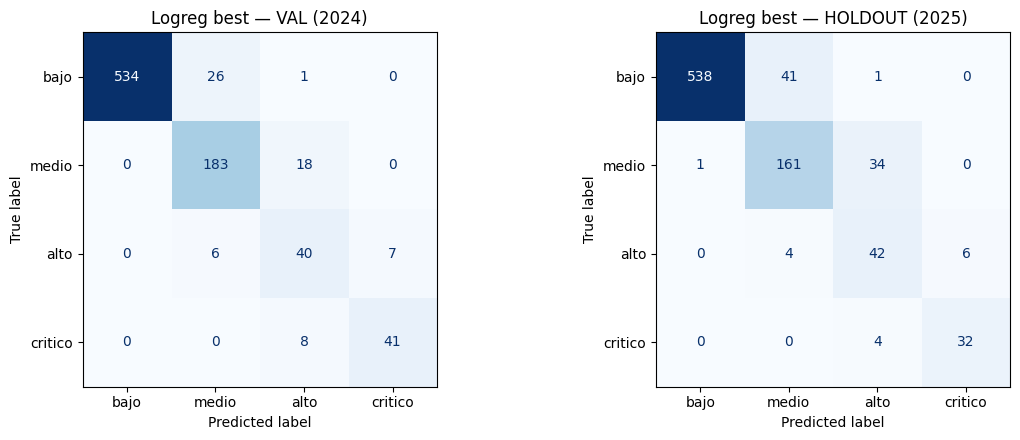

Guardado: reports\figures\07_logreg_confusion.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (y_true, y_pred, title) in zip(
    axes,
    [(y_val, y_val_pred, "VAL (2024)"), (y_holdout, y_holdout_pred, "HOLDOUT (2025)")],
):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"Logreg best — {title}")

plt.tight_layout()
cm_path = FIGURES_DIR / "07_logreg_confusion.png"
plt.savefig(cm_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {cm_path.relative_to(PROJ_ROOT)}")

## 8. Curva de aprendizaje

Diagnostico bias/variance: ¿el modelo se beneficiaria de mas datos? ¿esta en *underfit* o en *overfit*?

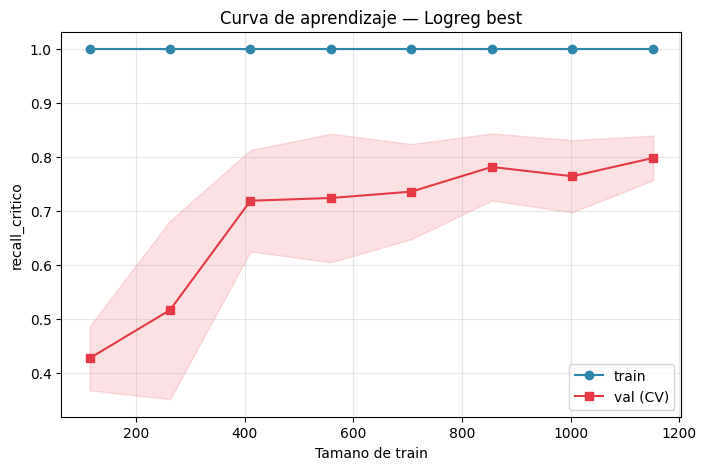

Guardado: reports\figures\07_logreg_learning_curve.png


In [10]:
train_sizes = np.linspace(0.1, 1.0, 8)
tscv_lc = TimeSeriesSplit(n_splits=5)

sizes, train_scores, val_scores = learning_curve(
    estimator=best,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=tscv_lc,
    scoring=scorers[PRIMARY_METRIC],
    n_jobs=-1,
    shuffle=False,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, train_scores.mean(axis=1), "o-", label="train", color="#2E86AB")
ax.fill_between(sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="#2E86AB")
ax.plot(sizes, val_scores.mean(axis=1), "s-", label="val (CV)", color="#E63946")
ax.fill_between(sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#E63946")
ax.set_xlabel("Tamano de train")
ax.set_ylabel(f"{PRIMARY_METRIC}")
ax.set_title("Curva de aprendizaje — Logreg best")
ax.legend()
ax.grid(alpha=0.3)
lc_path = FIGURES_DIR / "07_logreg_learning_curve.png"
plt.savefig(lc_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {lc_path.relative_to(PROJ_ROOT)}")

## 9. Curva de validacion sobre `C`

Mantenemos `penalty` y `class_weight` del mejor combo, variamos solo `C` para ver el *sweet spot* de regularizacion.

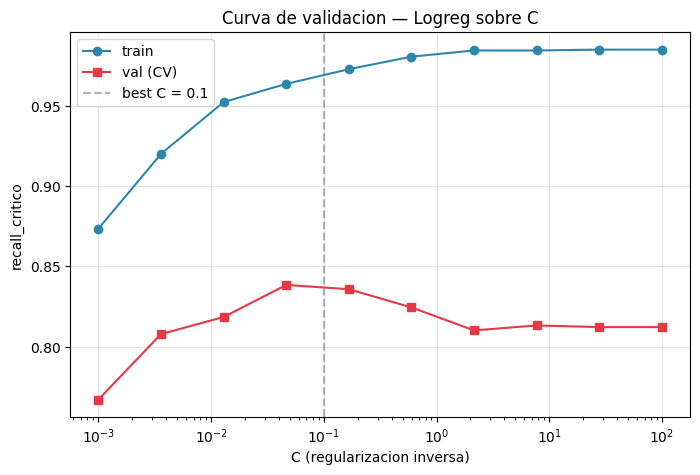

Guardado: reports\figures\07_logreg_validation_curve.png


In [11]:
C_range = np.logspace(-3, 2, 10)
vc_estimator = LogisticRegression(
    solver="saga", max_iter=4000, random_state=RANDOM_STATE, n_jobs=-1,
    penalty=grid.best_params_["penalty"],
    class_weight=grid.best_params_["class_weight"],
)
train_vc, val_vc = validation_curve(
    estimator=vc_estimator,
    X=X_train,
    y=y_train,
    param_name="C",
    param_range=C_range,
    cv=TimeSeriesSplit(n_splits=5),
    scoring=scorers[PRIMARY_METRIC],
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(C_range, train_vc.mean(axis=1), "o-", label="train", color="#2E86AB")
ax.semilogx(C_range, val_vc.mean(axis=1), "s-", label="val (CV)", color="#E63946")
ax.axvline(grid.best_params_["C"], ls="--", color="gray", alpha=0.6, label=f"best C = {grid.best_params_['C']}")
ax.set_xlabel("C (regularizacion inversa)")
ax.set_ylabel(PRIMARY_METRIC)
ax.set_title("Curva de validacion — Logreg sobre C")
ax.legend()
ax.grid(alpha=0.3)
vc_path = FIGURES_DIR / "07_logreg_validation_curve.png"
plt.savefig(vc_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {vc_path.relative_to(PROJ_ROOT)}")

## 10. Coeficientes — interpretabilidad

Top 15 *features* con mayor coeficiente absoluto para la clase `critico`.

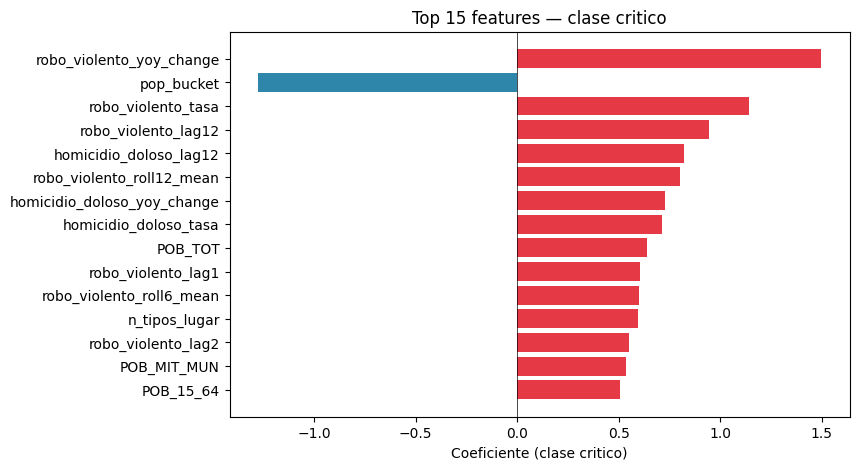

Guardado: reports\figures\07_logreg_coefficients.png


In [12]:
coefs = pd.DataFrame(best.coef_, columns=X_train.columns, index=CLASS_NAMES)
top_critico = coefs.loc["critico"].abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#E63946" if coefs.loc["critico", f] > 0 else "#2E86AB" for f in top_critico.index]
ax.barh(top_critico.index[::-1], [coefs.loc["critico", f] for f in top_critico.index[::-1]],
        color=colors[::-1])
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Coeficiente (clase critico)")
ax.set_title("Top 15 features — clase critico")
coef_path = FIGURES_DIR / "07_logreg_coefficients.png"
plt.savefig(coef_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardado: {coef_path.relative_to(PROJ_ROOT)}")

## 11. Guardar modelo + registrar en MLflow

In [13]:
model_path = MODELS_DIR / "logreg_best.joblib"
joblib.dump(best, model_path)
print(f"Modelo guardado: {model_path.relative_to(PROJ_ROOT)}")

if MLFLOW_ACTIVE:
    with mlflow.start_run(run_name=f"logreg_best_C{grid.best_params_['C']}_{grid.best_params_['penalty']}") as run:
        mlflow.set_tags({
            "model_family": "logistic_regression",
            "stage": "baseline",
            "validation": "TimeSeriesSplit_5",
            "refit_metric": PRIMARY_METRIC,
        })
        mlflow.log_params(grid.best_params_)
        mlflow.log_param("solver", "saga")
        mlflow.log_param("max_iter", 4000)
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_param("n_train", X_train.shape[0])

        mlflow.log_metric("cv_recall_critico", grid.best_score_)
        for k, v in {**metrics_val, **metrics_holdout}.items():
            mlflow.log_metric(k, float(v))

        for fig_path in [cm_path, lc_path, vc_path, coef_path]:
            mlflow.log_artifact(str(fig_path), artifact_path="figures")

        mlflow.sklearn.log_model(best, "model")
        print(f"[MLflow] run registrado: {run.info.run_id}")

        # Tambien loggear cada combo de la grid como un nested run
        for i, row in cv_results.iterrows():
            with mlflow.start_run(run_name=f"grid_trial_{i}", nested=True):
                mlflow.set_tag("model_family", "logistic_regression")
                mlflow.set_tag("stage", "grid_trial")
                for p in ["C", "penalty", "class_weight"]:
                    mlflow.log_param(p, row[f"param_{p}"])
                for m in ["recall_critico", "precision_critico", "f1_macro", "accuracy"]:
                    mlflow.log_metric(f"cv_{m}", float(row[f"mean_test_{m}"]))
                    mlflow.log_metric(f"cv_{m}_std", float(row[f"std_test_{m}"]))
else:
    print("[MLflow] inactivo — modelo y figuras guardados localmente solamente.")

Modelo guardado: models\logreg_best.joblib


2026/05/17 18:24:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/17 18:24:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[MLflow] run registrado: 8ad340da7f3b41db89a345adc807c737
🏃 View run grid_trial_0 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/1/runs/cb6fa0f9b70b4a0098f207ddb5d9d1bf
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/1
🏃 View run grid_trial_1 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/1/runs/794cf02d07ae4c829d44efdef305dde5
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/1
🏃 View run grid_trial_2 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/1/runs/3eead176ad954bc383af496e2c8158d2
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/1
🏃 View run grid_trial_3 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/1/runs/618a5c0a49164796add1370e6ebd8dca
🧪 View experiment at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/1
🏃 View run grid_trial_4 at: https://dagshub.com/RovleZMex/sonAlert.mlflow/#/experiments/1/runs

## 12. Diagnostico y proximos pasos

> :memo: **Llenar esta seccion despues de correr el notebook.** El esqueleto de abajo te orienta.

### Lectura del baseline

- **Metrica primaria (recall_critico):** _____ en val / _____ en holdout. Threshold deseable: > 0.85.
- **Precision_critico:** _____ en val / _____ en holdout. Threshold deseable: > 0.70.
- **F1_macro:** _____ en val / _____ en holdout. Threshold deseable: > 0.65.

### Diagnostico bias/variance

Observa la curva de aprendizaje:

- **Si train y val convergen y se quedan bajos** → underfitting (alto bias). Justifica probar modelos mas expresivos (SVM kernel RBF, RF, GB) — capitulo 08-09.
- **Si train >> val y la brecha no se cierra al aumentar datos** → overfitting (alta varianza). Justifica aumentar regularizacion (`C` mas chica), o `penalty='l1'` para *feature selection*.
- **Si val sigue subiendo al final** → mas datos ayudarian. No tenemos mas, asi que esto es un techo natural.

### Recomendaciones para los siguientes notebooks

1. **Companero 1 (08):** SVM kernel RBF + Random Forest. SVM debe captar la no-linealidad que la logistica no puede; RF da feature importance "libre".
2. **Companero 2 (09):** Gradient Boosting (XGBoost + LightGBM). Es el favorito para datos tabulares con relaciones no lineales y *features* heterogeneas.
3. **Si todos los modelos clasicos se quedan cortos en `recall_critico`** → justificar pasar a NN espaciotemporal (ver `reports/02_modelo_neuronal_o_no.md`).

### Notas operativas

- El run quedo registrado en MLflow / DagsHub bajo el experimento `baseline_logistic`.
- El modelo *best* esta en `models/logreg_best.joblib` — para versionarlo: `dvc add models/logreg_best.joblib && git add models/logreg_best.joblib.dvc && dvc push`.